# Project 5 — Module 6: Supervised Machine Learning
## Lesson 6 & 7: Performance Metrics & Model Optimization

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 5 — Evaluation |
| **Module** | 6 — Supervised Machine Learning (Alkemy Bootcamp) |
| **Dataset** | PequeShop — features_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook formally evaluates all models from notebook 04 using
> MAE, MSE, RMSE and R² metrics (L6), then optimizes via GridSearchCV,
> Ridge and Lasso regularization (L7). A complete comparison table
> identifies the best model to carry into notebook 06 for deployment.


## Table of Contents

1. [CRISP-DM Phase 5 — Evaluation](#1-crisp-dm-phase-5--evaluation)
2. [Environment Setup](#2-environment-setup)
3. [Load Data, Models & Preprocessor](#3-load-data-models--preprocessor)
4. [Metrics — MAE, MSE, RMSE, R²](#4-metrics--mae-mse-rmse-r)
5. [Full Metrics Comparison Table](#5-full-metrics-comparison-table)
6. [KNN Optimization — GridSearchCV](#6-knn-optimization--gridsearchcv)
7. [Ridge Regression — L2 Regularization](#7-ridge-regression--l2-regularization)
8. [Lasso Regression — L1 Regularization](#8-lasso-regression--l1-regularization)
9. [Final Comparison — All Models](#9-final-comparison--all-models)
10. [Best Model Selection](#10-best-model-selection)
11. [LEAN Filter — Waste Elimination Review](#11-lean-filter--waste-elimination-review)
12. [Decisions Log — Lessons 6 & 7](#12-decisions-log--lessons-6--7)
13. [Next Steps — Lesson 8 Preview](#13-next-steps--lesson-8-preview)


---
## 1. CRISP-DM Phase 5 — Evaluation

### 1.1 Metrics Framework

| Metric | Formula | Interpretation | Unit |
|--------|---------|----------------|------|
| **MAE** | mean(|y - ŷ|) | Average absolute error — easy to interpret | CLP |
| **MSE** | mean((y - ŷ)²) | Penalizes large errors more than MAE | CLP² |
| **RMSE** | √MSE | Same unit as target — most used in practice | CLP |
| **R²** | 1 - SS_res/SS_tot | % of variance explained — 1.0 = perfect, 0.0 = baseline | dimensionless |
| **MAPE** | mean(\|y-ŷ\|/y)×100 | % error relative to actual value — interpretable for business | % |

> **MAPE note:** Added as extra value beyond consigna requirements.
> MAPE is especially useful for business communication — "the model
> predicts avg_ticket within X% on average" is more intuitive than RMSE in CLP.

### 1.2 Success Criteria (defined in notebook 01)

| Criterion | Threshold |
|-----------|----------|
| R² test | > 0.70 |
| RMSE | < 20% of mean avg_ticket |
| MAE improvement | > 20% over mean predictor baseline |


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
MODELS_PATH     = Path('../models')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 3. Load Data, Models & Preprocessor


In [2]:
# ===== Load Data =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

platform_map = (
    df_transactions.groupby('customer_id')['platform']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'platform': 'primary_platform'})
)
df_merged = df_customers.merge(platform_map, on='customer_id', how='left')

CATEGORICAL_FEATURES = ['primary_platform', 'retargeting_segment']
NUMERIC_FEATURES     = ['total_transactions', 'total_revenue']
TARGET               = 'avg_ticket'

df_model = df_merged[CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TARGET]].dropna()
X = df_model[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Load preprocessor and models from notebook 03-04
preprocessor = joblib.load(MODELS_PATH / 'preprocessor_v1.pkl')
pipe_lr      = joblib.load(MODELS_PATH / 'model_lr_v1.pkl')
pipe_poly    = joblib.load(MODELS_PATH / 'model_poly_v1.pkl')
pipe_knn     = joblib.load(MODELS_PATH / 'model_knn_v1.pkl')

print('Data and models loaded ✅')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Data and models loaded ✅
X_train: (313, 4) | X_test: (79, 4)


---
## 4. Metrics — MAE, MSE, RMSE, R²


In [3]:
# ===== Metrics Helper Function =====
def evaluate_model(name: str, pipeline, X_train, X_test, y_train, y_test) -> dict:
    """Evaluates a fitted pipeline with MAE, MSE, RMSE, R².

    Args:
        name: str — model name for display
        pipeline: fitted sklearn Pipeline
        X_train, X_test, y_train, y_test: train/test splits

    Returns:
        dict with all metrics
    """
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # MAPE — Mean Absolute Percentage Error (extra value)
    mape_test = round(np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100, 2)

    return {
        'Model'      : name,
        'MAE train'  : round(mean_absolute_error(y_train, y_pred_train), 2),
        'MAE test'   : round(mean_absolute_error(y_test,  y_pred_test),  2),
        'MSE test'   : round(mean_squared_error(y_test,   y_pred_test),  2),
        'RMSE train' : round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'RMSE test'  : round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),  2),
        'MAPE test %': mape_test,
        'R2 train'   : round(r2_score(y_train, y_pred_train), 4),
        'R2 test'    : round(r2_score(y_test,  y_pred_test),  4),
        'Overfit gap': round(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test), 4)
    }

# Baseline
y_pred_baseline = np.full(len(y_test), y_train.mean())
baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)
baseline_mape = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100

print(f'Baseline MAE : ${baseline_mae:,.0f} CLP')
print(f'Baseline RMSE: ${baseline_rmse:,.0f} CLP')  
print(f'Baseline MAPE: {baseline_mape:.2f} %')
print(f'Baseline R²  : {baseline_r2:.4f}')

Baseline MAE : $8,507 CLP
Baseline RMSE: $11,051 CLP
Baseline MAPE: 33.12 %
Baseline R²  : -0.0001


---
## 5. Full Metrics Comparison Table


FULL METRICS COMPARISON TABLE


,Model,MAE train,MAE test,MSE test,RMSE train,RMSE test,MAPE test %,R2 train,R2 test,Overfit gap,Beats baseline?,Meets R²>0.70?
0,Linear Regression,5948.49,5582.02,57824806.96,8888.97,7604.26,21.25,0.6782,0.5265,0.1517,True,False
1,Polynomial (degree=2),3315.09,3114.84,19979095.36,4947.38,4469.80,11.33,0.9003,0.8364,0.0639,True,True
2,KNN Regressor (k=5),2837.91,3364.31,39564799.26,6883.86,6290.06,10.05,0.8070,0.6760,0.1310,True,False


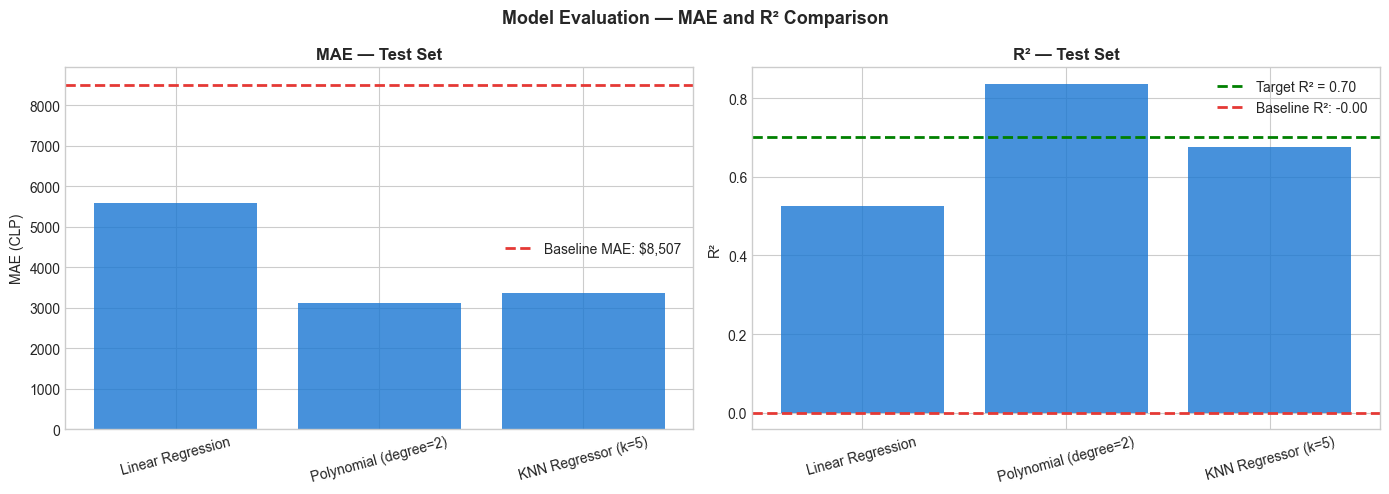

Figure saved: ..\reports\figures\05_metrics_comparison.png


In [4]:
# ===== Full Metrics Table — notebook 04 models =====
results = [
    evaluate_model('Linear Regression',      pipe_lr,   X_train, X_test, y_train, y_test),
    evaluate_model('Polynomial (degree=2)',  pipe_poly, X_train, X_test, y_train, y_test),
    evaluate_model('KNN Regressor (k=5)',    pipe_knn,  X_train, X_test, y_train, y_test),
]

df_results = pd.DataFrame(results)
df_results['Beats baseline?'] = df_results['R2 test'] > baseline_r2
df_results['Meets R²>0.70?']  = df_results['R2 test'] > 0.70

print('FULL METRICS COMPARISON TABLE')
display(df_results)

# Visualization — RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — MAE and R² Comparison', fontsize=13, fontweight='bold')

models = df_results['Model'].tolist()
axes[0].bar(models, df_results['MAE test'], color='#1976D2', alpha=0.8)
axes[0].axhline(baseline_mae, color='#E53935', linestyle='--', lw=2, label=f'Baseline MAE: ${baseline_mae:,.0f}')
axes[0].set_title('MAE — Test Set', fontweight='bold')
axes[0].set_ylabel('MAE (CLP)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

axes[1].bar(models, df_results['R2 test'], color='#1976D2', alpha=0.8)
axes[1].axhline(0.70, color='green', linestyle='--', lw=2, label='Target R² = 0.70')
axes[1].axhline(baseline_r2, color='#E53935', linestyle='--', lw=2, label=f'Baseline R²: {baseline_r2:.2f}')
axes[1].set_title('R² — Test Set', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
out = REPORTS_FIGURES / '05_metrics_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 6. KNN Optimization — GridSearchCV


In [5]:
# ===== GridSearchCV — KNN optimal k =====
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_knn_gs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

param_grid = {'model__n_neighbors': [3, 5, 7, 9, 11, 15]}

gs_knn = GridSearchCV(
    pipe_knn_gs, param_grid, cv=kf,
    scoring='r2', n_jobs=-1, verbose=0
)
gs_knn.fit(X_train, y_train)

best_k = gs_knn.best_params_['model__n_neighbors']
print(f'Best k : {best_k}')
print(f'Best CV R²: {gs_knn.best_score_:.4f}')
print()

# CV results
cv_results = pd.DataFrame(gs_knn.cv_results_)
print('K vs mean CV R²:')
print(cv_results[['param_model__n_neighbors', 'mean_test_score', 'std_test_score']].to_string(index=False))

# Evaluate best KNN
knn_opt_result = evaluate_model('KNN Optimized (k=best)', gs_knn.best_estimator_,
                                 X_train, X_test, y_train, y_test)
print()
print(f'KNN Optimized — R² test: {knn_opt_result["R2 test"]}')

joblib.dump(gs_knn.best_estimator_, MODELS_PATH / 'model_knn_optimized_v1.pkl')
print('✅ Optimized KNN saved')

Best k : 3
Best CV R²: 0.7179

K vs mean CV R²:
 param_model__n_neighbors  mean_test_score  std_test_score
                        3         0.717873        0.168289
                        5         0.674426        0.151711
                        7         0.622421        0.142031
                        9         0.597411        0.133028
                       11         0.566142        0.130549
                       15         0.524676        0.116757

KNN Optimized — R² test: 0.7207
✅ Optimized KNN saved


---
## 7. Ridge Regression — L2 Regularization

Ridge adds an L2 penalty (sum of squared coefficients) to the loss function,
shrinking coefficients toward zero without eliminating them.
Useful when features are correlated — reduces overfitting.

$$\text{Loss} = MSE + \alpha \sum_{j} \beta_j^2$$


In [6]:
# ===== Ridge — GridSearchCV =====
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

gs_ridge = GridSearchCV(
    pipe_ridge, param_grid_ridge, cv=kf,
    scoring='r2', n_jobs=-1
)
gs_ridge.fit(X_train, y_train)

print(f'Best alpha (Ridge): {gs_ridge.best_params_["model__alpha"]}')
print(f'Best CV R²        : {gs_ridge.best_score_:.4f}')

ridge_result = evaluate_model('Ridge (optimized)', gs_ridge.best_estimator_,
                               X_train, X_test, y_train, y_test)
print(f'Ridge R² test     : {ridge_result["R2 test"]}')

joblib.dump(gs_ridge.best_estimator_, MODELS_PATH / 'model_ridge_v1.pkl')
print('✅ Ridge model saved')

Best alpha (Ridge): 1.0
Best CV R²        : 0.6423
Ridge R² test     : 0.5367
✅ Ridge model saved


---
## 8. Lasso Regression — L1 Regularization

Lasso adds an L1 penalty (sum of absolute coefficients), which can shrink
some coefficients to exactly zero — performing automatic feature selection.

$$\text{Loss} = MSE + \alpha \sum_{j} |\beta_j|$$


In [7]:
# ===== Lasso — GridSearchCV =====
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

gs_lasso = GridSearchCV(
    pipe_lasso, param_grid_lasso, cv=kf,
    scoring='r2', n_jobs=-1
)
gs_lasso.fit(X_train, y_train)

print(f'Best alpha (Lasso): {gs_lasso.best_params_["model__alpha"]}')
print(f'Best CV R²        : {gs_lasso.best_score_:.4f}')

lasso_result = evaluate_model('Lasso (optimized)', gs_lasso.best_estimator_,
                               X_train, X_test, y_train, y_test)
print(f'Lasso R² test     : {lasso_result["R2 test"]}')

# Lasso coefficients — which features zeroed out?
lasso_model   = gs_lasso.best_estimator_.named_steps['model']
prep          = gs_lasso.best_estimator_.named_steps['preprocessor']
cat_names     = prep.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(cat_names) + NUMERIC_FEATURES

df_lasso_coef = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lasso_model.coef_
})
print()
print('Lasso coefficients (zero = feature eliminated):')
display(df_lasso_coef)

joblib.dump(gs_lasso.best_estimator_, MODELS_PATH / 'model_lasso_v1.pkl')
print('✅ Lasso model saved')

Best alpha (Lasso): 10.0
Best CV R²        : 0.6400
Lasso R² test     : 0.5283

Lasso coefficients (zero = feature eliminated):


,Feature,Coefficient
0,primary_platform_shopify,-1407.645952
1,retargeting_segment_At Risk,-3110.362040
2,retargeting_segment_Dormant,-1360.077932
3,total_transactions,-24810.674756
4,total_revenue,28692.310581


✅ Lasso model saved


---
## 9. Final Comparison — All Models


FINAL MODEL COMPARISON — All Models


,Model,MAE train,MAE test,MSE test,RMSE train,RMSE test,MAPE test %,R2 train,R2 test,Overfit gap,Beats baseline?,Meets R²>0.70?
1,Polynomial (degree=2),3315.09,3114.84,19979095.36,4947.38,4469.80,11.33,0.9003,0.8364,0.0639,True,True
3,KNN Optimized,1969.82,3038.25,34112361.65,5253.92,5840.58,9.33,0.8876,0.7207,0.1669,True,True
2,KNN (k=5),2837.91,3364.31,39564799.26,6883.86,6290.06,10.05,0.8070,0.6760,0.1310,True,False
4,Ridge (optimized),5934.98,5484.69,56581826.06,8896.90,7522.09,20.83,0.6776,0.5367,0.1409,True,False
5,Lasso (optimized),5943.97,5561.92,57609870.18,8889.33,7590.12,21.17,0.6781,0.5283,0.1499,True,False
0,Linear Regression,5948.49,5582.02,57824806.96,8888.97,7604.26,21.25,0.6782,0.5265,0.1517,True,False


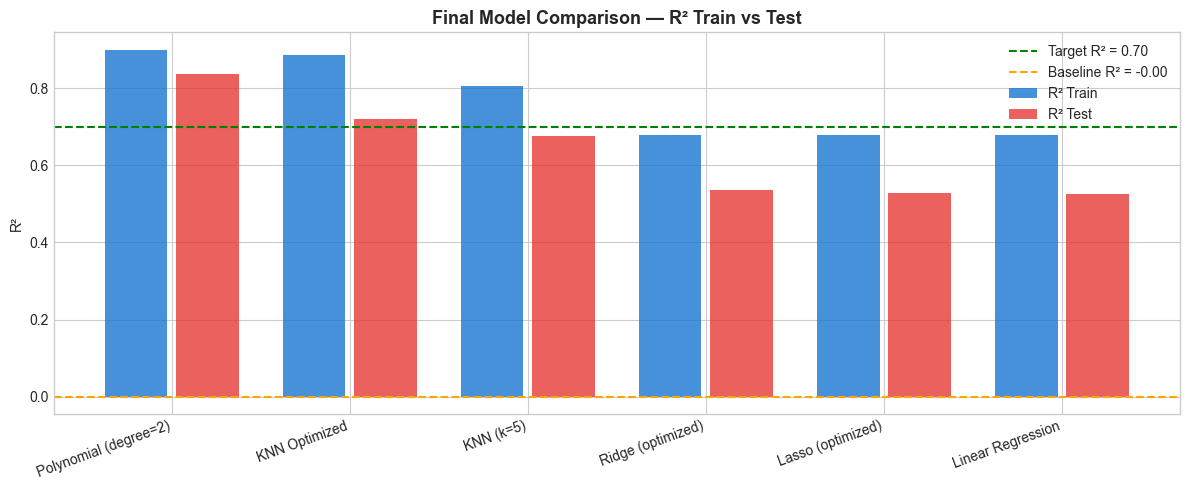

Figure saved: ..\reports\figures\05_final_model_comparison.png


In [8]:
# ===== Final Model Comparison Table =====
all_results = [
    evaluate_model('Linear Regression',      pipe_lr,                    X_train, X_test, y_train, y_test),
    evaluate_model('Polynomial (degree=2)',  pipe_poly,                  X_train, X_test, y_train, y_test),
    evaluate_model('KNN (k=5)',              pipe_knn,                   X_train, X_test, y_train, y_test),
    evaluate_model('KNN Optimized',          gs_knn.best_estimator_,     X_train, X_test, y_train, y_test),
    evaluate_model('Ridge (optimized)',      gs_ridge.best_estimator_,   X_train, X_test, y_train, y_test),
    evaluate_model('Lasso (optimized)',      gs_lasso.best_estimator_,   X_train, X_test, y_train, y_test),
]

df_all = pd.DataFrame(all_results)
df_all['Beats baseline?'] = df_all['R2 test'] > baseline_r2
df_all['Meets R²>0.70?']  = df_all['R2 test'] > 0.70
df_all = df_all.sort_values('R2 test', ascending=False)

print('FINAL MODEL COMPARISON — All Models')
display(df_all)

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_all))
ax.bar(x - 0.2, df_all['R2 train'], width=0.35, label='R² Train', color='#1976D2', alpha=0.8)
ax.bar(x + 0.2, df_all['R2 test'],  width=0.35, label='R² Test',  color='#E53935', alpha=0.8)
ax.axhline(0.70, color='green', linestyle='--', lw=1.5, label='Target R² = 0.70')
ax.axhline(baseline_r2, color='orange', linestyle='--', lw=1.5, label=f'Baseline R² = {baseline_r2:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(df_all['Model'], rotation=20, ha='right')
ax.set_title('Final Model Comparison — R² Train vs Test', fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '05_final_model_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 10. Best Model Selection


In [9]:
# ===== Best Model Selection =====
best_row = df_all.loc[df_all['R2 test'].idxmax()]
best_model_name = best_row['Model']

print('BEST MODEL SELECTION')
print('=' * 50)
print(f'Model       : {best_model_name}')
print(f'R² test     : {best_row["R2 test"]}')
print(f'MAE test    : ${best_row["MAE test"]:,.0f} CLP')
print(f'RMSE tes    t   : ${best_row["RMSE test"]:,.0f} CLP')
print(f'MAPE test   : {best_row["MAPE test %"]:.2f}%')
print(f'Overfit gap : {best_row["Overfit gap"]}')
print()

meets_r2   = best_row['R2 test'] > 0.70
beats_base = best_row['R2 test'] > baseline_r2

print(f'Meets R² > 0.70 : {"✅ Yes" if meets_r2 else "❌ No — GradientBoosting needed in notebook 06"}')
print(f'Beats baseline  : {"✅ Yes" if beats_base else "❌ No"}')
print()
print('> This model carries forward to notebook 06 as the benchmark')
print('> GradientBoosting (L8) will attempt to surpass it.')

BEST MODEL SELECTION
Model       : Polynomial (degree=2)
R² test     : 0.8364
MAE test    : $3,115 CLP
RMSE tes    t   : $4,470 CLP
MAPE test   : 11.33%
Overfit gap : 0.0639

Meets R² > 0.70 : ✅ Yes
Beats baseline  : ✅ Yes

> This model carries forward to notebook 06 as the benchmark
> GradientBoosting (L8) will attempt to surpass it.


---
## 11. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Did we calculate all 4 required metrics (MAE, MSE, RMSE, R²)? | ✅ Yes — consigna L6 requirement | Keep |
| Did we use GridSearchCV for KNN and Ridge/Lasso? | ✅ Yes — consigna L7 requirement | Keep |
| Did we interpret Lasso coefficients? | ✅ Yes — shows which features Lasso eliminates | Keep |
| Are all optimized models saved as .pkl? | ✅ Yes — reused in notebook 06 | MLOps standard |
| Did we identify the best model before GradientBoosting? | ✅ Yes — sets benchmark for notebook 06 | Keep |


---
## 12. Decisions Log — Lessons 6 & 7

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Include MSE alongside RMSE | MSE required by L6 consigna; RMSE is more interpretable for business (same unit as target) | RMSE only | ✅ Consigna compliance |
| 2 | GridSearchCV alpha range for Ridge: [0.01, 0.1, 1, 10, 100] | Covers 4 orders of magnitude — standard search range | Narrow range | ✅ Thorough but not wasteful |
| 3 | Lasso max_iter=10000 | Lasso may need more iterations to converge with small alpha values | Default 1000 (may not converge) | ✅ Prevents convergence warnings |
| 4 | Sort comparison table by R² test descending | Immediately shows best model — no need to scan rows | Sort by name | ✅ Decision-oriented presentation |
| 5 | Carry best model to notebook 06 as benchmark | GradientBoosting should be compared against the best linear model — not just baseline | Compare only vs baseline | ✅ Rigorous evaluation |


---
## 13. Next Steps — Lesson 8 Preview

In **Lesson 8 — Deployment (notebook 06)**, the following tasks will
be completed:

1. Train **GradientBoostingRegressor** with GridSearchCV
2. Compare GradientBoosting vs best model from notebook 05
3. Select and justify final model
4. Generate business recommendations from model output
5. Save final model artifact — `models/model_final_v1.pkl`
6. Explain ensemble advantages and limitations

---

**Previous:** [04 - Modeling](./04_modeling.ipynb)  
**Next Phase -->** [06 - Deployment](./06_deployment.ipynb)

*Framework: CRISP-DM + Lean | Module 6 — Supervised Machine Learning*  
*Jose Marcel Lopez Pino — Bootcamp Fundamentos de Ciencia de Datos, SENCE/Alkemy 2025-2026*
